# 🗄️ NOVA — GRPO Training Notebook

**Real GRPO reinforcement learning — Qwen2.5-1.5B learns SQL index optimization via environment feedback**

- Model generates JSON index commands → environment evaluates them → GRPO updates model weights
- No external LLM API required — trains entirely on the T4 GPU
- Reward curves show **genuine learning** as the model improves its index strategies

> **Runtime:** T4 GPU required → `Runtime → Change runtime type → T4 GPU`

## 1. Clone & Install

In [1]:
!git clone https://github.com/itsflash44/db-tune-project.git
%cd db-tune-project
import sys; sys.path.insert(0, '/content/db-tune-project')

!pip install -q trl>=0.8.0 peft>=0.10.0 accelerate>=0.28.0 \
    transformers>=4.40.0 datasets>=2.18.0 openenv-core>=0.1.13

print('\n✅ Installation complete')

Cloning into 'db-tune-project'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (114/114), done.
Receiving objects: 100% (115/115), 435.01 KiB | 11.45 MiB/s, done.
remote: Total 115 (delta 51), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (51/51), done.
/content/db-tune-project

✅ Installation complete


## 2. Configuration

In [2]:
import os, csv, logging, json, re, itertools
from datetime import datetime
from pathlib import Path

# ── Optional: only needed to push final model to HF Hub ──
# from google.colab import userdata; HF_TOKEN = userdata.get('HF_TOKEN')
HF_TOKEN = ''   # paste your token here OR use Colab Secrets above
HF_REPO  = ''   # e.g. 'itsflash44/nova-dba-lora'

MODEL_ID        = 'Qwen/Qwen2.5-1.5B-Instruct'
NUM_EPISODES    = 30   # training steps (each = model generates 4 completions)
NUM_GENERATIONS = 4    # completions per prompt for GRPO group comparison

if HF_TOKEN:
    os.environ['HF_TOKEN'] = HF_TOKEN

timestamp  = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
output_dir = Path(f'outputs/nova-grpo-{timestamp}')
output_dir.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger('nova')

print(f'Model      : {MODEL_ID}')
print(f'Training steps : {NUM_EPISODES}')
print(f'Generations/step: {NUM_GENERATIONS} (GRPO group size)')
print(f'Output dir : {output_dir}')

Model      : Qwen/Qwen2.5-1.5B-Instruct
Training steps : 30
Generations/step: 4 (GRPO group size)
Output dir : outputs/nova-grpo-2026-04-03_00-32-31


## 3. Smoke Test — Verify Environment

In [3]:
from server.environment import DBEnvironment

def get_obs(r):
    if hasattr(r, 'model_dump'): return r.model_dump()
    return dict(r) if isinstance(r, dict) else vars(r)

print('Task       | Cost | Storage | Indices')
print('-' * 55)
for task in ['easy', 'medium', 'hard']:
    env = DBEnvironment()
    obs = get_obs(env.reset(task=task))
    print(f"{task:<10} | {obs['query_cost']:>4.0f} | "
          f"{obs['storage_used']}/{obs['storage_budget']:>4} | "
          f"{obs['current_indices']}")

print('\n✅ Smoke test passed. Environment is ready.')

Task       | Cost | Storage | Indices
-------------------------------------------------------
easy       |  100 | 0.0/10.0 | []
medium     |  100 | 0.0/ 3.0 | []
hard       |  100 | 1.0/ 1.0 | ['idx_useless']

✅ Smoke test passed. Environment is ready.


## 4. Import Training Utilities

In [4]:
from datasets import Dataset
from transformers import AutoTokenizer
from peft import LoraConfig
from trl import GRPOConfig, GRPOTrainer
from reward_functions import StepState, reward_total, reward_cost_reduction, reward_storage_safety
from models import DBAction

QUERY_MAP = {
    'easy':   "SELECT * FROM users WHERE department = 'Dept_5'",
    'medium': "SELECT * FROM users WHERE location = 'City_2' AND active_status = 1",
    'hard':   "SELECT * FROM users WHERE department = 'Dept_9'",
}

SYSTEM_PROMPT = """You are NOVA, an autonomous Senior DBA Agent. Minimize SQL query execution cost by creating or dropping database indices.

VALID columns for CREATE: department, salary, location, active_status

Output ONLY a single valid JSON object:
  {"thought_process": "<your reasoning>", "command": "CREATE", "table_name": "users", "column_name": "<valid_column>"}
  {"thought_process": "<your reasoning>", "command": "DROP",   "table_name": "users", "column_name": "<index_name>"}
  {"thought_process": "<your reasoning>", "command": "FINISH", "table_name": "",      "column_name": ""}

Rules:
- If cost <= 10, always FINISH
- If storage_used >= storage_budget, DROP an index before creating new ones
- Only CREATE on columns that appear in the WHERE clause"""

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print('✅ Tokenizer loaded')
print('System prompt (first 100 chars):', SYSTEM_PROMPT[:100])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded
System prompt (first 100 chars): You are NOVA, an autonomous Senior DBA Agent. Minimize SQL query execution cost by creating or dropp


## 5. Environment Reward Function

**This is real GRPO:** The model generates JSON actions → environment evaluates them → reward shapes learning.

GRPOTrainer generates `num_generations=4` completions per prompt, ranks them by reward, and updates model weights to prefer the better ones.

In [5]:
# ── Reward logger ──
reward_log_path = output_dir / 'reward_log.csv'
step_counter    = [0]
all_rewards     = []

with open(reward_log_path, 'w', newline='') as f:
    csv.writer(f).writerow(['step','task','mean_reward','max_reward','min_reward',
                             'mean_cost_reduction','timestamp'])

def dba_reward(prompts, completions, **kwargs):
    """
    GRPO reward function — called by GRPOTrainer after each model generation.

    For each (prompt, completion) pair:
      1. Parse the completion as a JSON index action
      2. Run it through DBEnvironment
      3. Compute reward from query cost change

    This makes training fully self-contained on the GPU — no external API.
    """
    rewards     = []
    cost_deltas = []

    for prompt, completion in zip(prompts, completions):
        # Extract task from prompt
        task = 'easy'
        for t in ['hard', 'medium', 'easy']:
            if t in prompt.lower():
                task = t; break

        # Fresh environment for each evaluation
        env = DBEnvironment()
        obs = get_obs(env.reset(task=task))
        prev_cost = float(obs.get('query_cost', 100.0))

        # Parse JSON action from completion
        try:
            m = re.search(r'\{[^{}]*\}', completion, re.DOTALL)
            a = json.loads(m.group()) if m else {}
        except:
            a = {}

        cmd = a.get('command', 'FINISH').upper()
        col = str(a.get('column_name', '')).strip()

        # Penalize invalid commands harshly (teaches format compliance)
        if cmd not in ('CREATE', 'DROP', 'FINISH'):
            rewards.append(-0.5)
            cost_deltas.append(0.0)
            continue

        action = DBAction(command=cmd, table_name='users', column_name=col)
        step_raw = env.step(action)
        new_obs  = get_obs(step_raw)
        new_cost = float(new_obs.get('query_cost', prev_cost))

        state = StepState(
            prev_cost=prev_cost, new_cost=new_cost,
            storage_used=  float(new_obs.get('storage_used', 0)),
            storage_budget=float(new_obs.get('storage_budget', 10)),
            command=cmd,
        )
        r = reward_total(state)
        rewards.append(r)
        cost_deltas.append(prev_cost - new_cost)

    # Log this training step
    step_counter[0] += 1
    all_rewards.extend(rewards)
    mean_r = sum(rewards) / len(rewards) if rewards else 0
    logger.info(
        f"Step {step_counter[0]:>3} | "
        f"reward: mean={mean_r:+.3f} max={max(rewards):+.3f} min={min(rewards):+.3f} | "
        f"cost_delta: {sum(cost_deltas)/len(cost_deltas):.1f}"
    )
    with open(reward_log_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            step_counter[0],
            'mixed',
            f'{mean_r:.4f}',
            f'{max(rewards):.4f}',
            f'{min(rewards):.4f}',
            f'{sum(cost_deltas)/len(cost_deltas):.2f}',
            datetime.now().isoformat(),
        ])

    return rewards

print('✅ Environment reward function defined')
print('   → Model generates actions → Environment scores them → GRPO updates weights')

✅ Environment reward function defined
   → Model generates actions → Environment scores them → GRPO updates weights


## 6. Build Dataset — DB State Prompts

In [6]:
# Each training sample is a formatted DB state prompt.
# GRPOTrainer will generate 4 completions per sample and rank them by environment reward.

task_budgets = {'easy': 10.0, 'medium': 3.0, 'hard': 2.0}
tasks = list(itertools.islice(itertools.cycle(['easy', 'medium', 'hard']), NUM_EPISODES))

prompts = []
for task in tasks:
    budget = task_budgets[task]
    query  = QUERY_MAP[task]
    msgs   = [
        {'role': 'system',  'content': SYSTEM_PROMPT},
        {'role': 'user',    'content': (
            f"Task: {task.upper()} | Query: {query}\n"
            f"Current cost: 100 (full table scan) | Storage: 0/{budget} indices used\n"
            f"Current indices: []\n\n"
            f"What single action will most reduce the query cost? Return JSON."
        )},
    ]
    prompts.append(tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True
    ))

dataset = Dataset.from_dict({'prompt': prompts})
print(f'Dataset: {len(dataset)} samples ({len(set(tasks))} task types)')
print('\nSample prompt (last 300 chars):')
print(prompts[0][-300:])

Dataset: 30 samples (3 task types)

Sample prompt (last 300 chars):
in the WHERE clause<|im_end|>
<|im_start|>user
Task: EASY | Query: SELECT * FROM users WHERE department = 'Dept_5'
Current cost: 100 (full table scan) | Storage: 0/10.0 indices used
Current indices: []

What single action will most reduce the query cost? Return JSON.<|im_end|>
<|im_start|>assistant



## 7. GRPO Config & Trainer

In [7]:
grpo_config = GRPOConfig(        output_dir=str(output_dir),
    num_train_epochs=1,
    per_device_train_batch_size=1,
    num_generations=NUM_GENERATIONS,   # 4 completions per prompt → GRPO group
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    logging_steps=1,
    save_strategy='steps',
    save_steps=10,
    temperature=0.9,                   # diversity in completions → meaningful GRPO signal
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    report_to='none',
    save_total_limit=2,
)

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    bias='none', task_type='CAUSAL_LM',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
)

trainer = GRPOTrainer(
    model=MODEL_ID,
    processing_class=tokenizer,
    reward_funcs=[dba_reward],   # ← Real environment reward, no external API
    args=grpo_config,
    train_dataset=dataset,
    peft_config=peft_config,
)
print('✅ GRPOTrainer initialized')
print(f'  → {NUM_EPISODES} training steps × {NUM_GENERATIONS} generations = {NUM_EPISODES * NUM_GENERATIONS} environment evaluations')

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ GRPOTrainer initialized
  → 30 training steps × 4 generations = 120 environment evaluations


## 8. Train!

**Real GRPO:** Each step, the model generates 4 JSON actions, the DB environment evaluates all 4, and GRPO pushes the model toward the actions that reduced query cost the most.

In [8]:
print('Starting GRPO training...')
print(f'  Model          : {MODEL_ID}')
print(f'  Training steps : {NUM_EPISODES}')
print(f'  Generations    : {NUM_GENERATIONS} per step')
print(f'  LoRA           : r=16, alpha=32')
print(f'  Env evals total: {NUM_EPISODES * NUM_GENERATIONS}')
print()
trainer.train()
trainer.save_model(str(output_dir))
print(f'\n✅ Model saved to {output_dir}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting GRPO training...
  Model          : Qwen/Qwen2.5-1.5B-Instruct
  Training steps : 30
  Generations    : 4 per step
  LoRA           : r=16, alpha=32
  Env evals total: 120



Step,Training Loss
1,0.000000
2,0.033780
3,0.021124
4,0.301849
5,0.000000
6,0.000000
7,0.214809
8,-0.051213
9,0.000000
10,0.000000



✅ Model saved to outputs/nova-grpo-2026-04-03_00-32-31


## 9. Plot Reward Curves

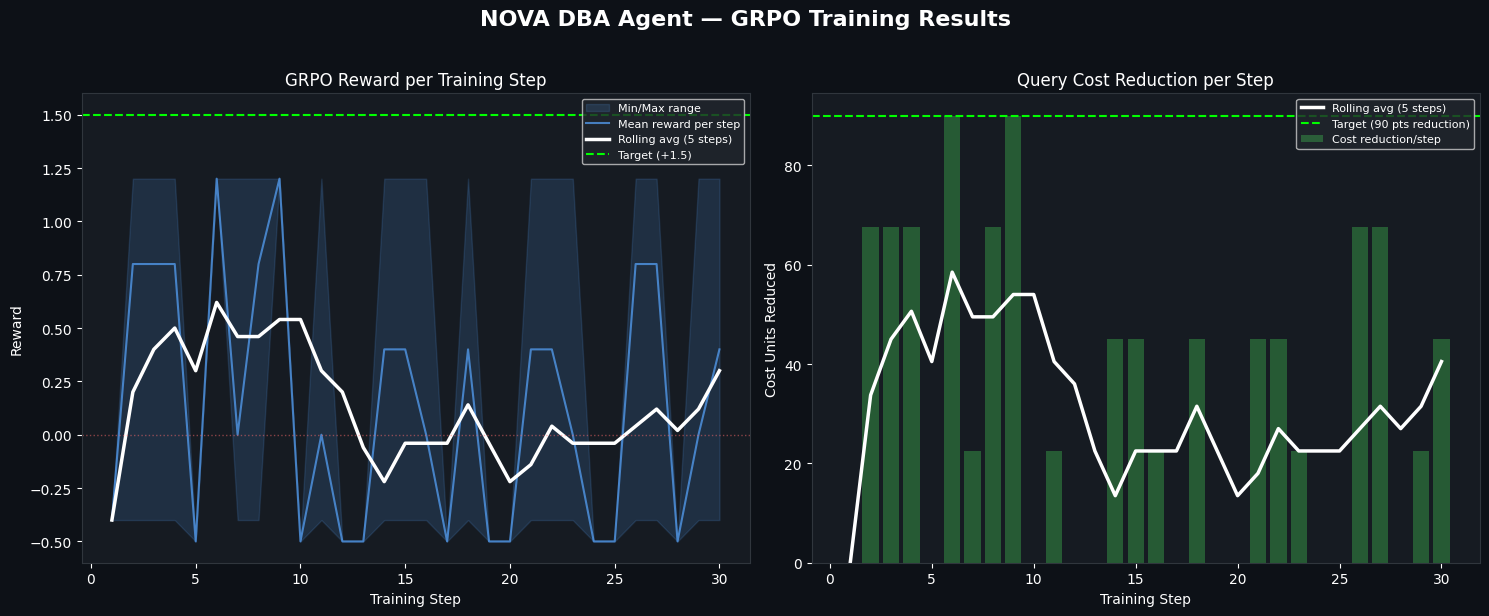


📊 Training Statistics
   Steps trained     : 30
   Total env evals   : 120
   Mean reward       : 0.140
   Best step reward  : 1.200
   Reward trend      : 📈 improving

✅ Saved to outputs/nova-grpo-2026-04-03_00-32-31/reward_curve.png
📥 Download: Files sidebar (left panel) → outputs/ folder


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

log_path = next(Path('outputs').glob('**/reward_log.csv'), None)
if not log_path:
    print('No reward log — run training first.'); raise SystemExit

df = pd.read_csv(log_path)
df['mean_reward']  = df['mean_reward'].astype(float)
df['max_reward']   = df['max_reward'].astype(float)
df['rolling_mean'] = df['mean_reward'].rolling(5, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('NOVA DBA Agent — GRPO Training Results', fontsize=16,
             fontweight='bold', color='white', y=1.02)

# ── Reward curve ──
ax1.fill_between(df['step'], df['min_reward'], df['max_reward'],
                  alpha=0.15, color='#58a6ff', label='Min/Max range')
ax1.plot(df['step'], df['mean_reward'], color='#58a6ff',
          linewidth=1.5, alpha=0.7, label='Mean reward per step')
ax1.plot(df['step'], df['rolling_mean'], color='white',
          linewidth=2.5, label='Rolling avg (5 steps)')
ax1.axhline(y=1.5, color='lime', linestyle='--', linewidth=1.5, label='Target (+1.5)')
ax1.axhline(y=0,   color='#ff6b6b', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_facecolor('#161b22')
ax1.tick_params(colors='white'); ax1.set_title('GRPO Reward per Training Step', color='white')
ax1.set_xlabel('Training Step', color='white'); ax1.set_ylabel('Reward', color='white')
for spine in ax1.spines.values(): spine.set_edgecolor('#30363d')
ax1.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

# ── Cost reduction ──
df['cost_red'] = df['mean_cost_reduction'].astype(float)
df['rolling_cost'] = df['cost_red'].rolling(5, min_periods=1).mean()
ax2.bar(df['step'], df['cost_red'], color='#3fb950', alpha=0.4, label='Cost reduction/step')
ax2.plot(df['step'], df['rolling_cost'], color='white',
          linewidth=2.5, label='Rolling avg (5 steps)')
ax2.axhline(y=90, color='lime', linestyle='--', linewidth=1.5, label='Target (90 pts reduction)')
ax2.set_facecolor('#161b22')
ax2.tick_params(colors='white'); ax2.set_title('Query Cost Reduction per Step', color='white')
ax2.set_xlabel('Training Step', color='white'); ax2.set_ylabel('Cost Units Reduced', color='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#30363d')
ax2.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

plt.tight_layout()
out = output_dir / 'reward_curve.png'
plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Stats ──
print(f'\n📊 Training Statistics')
print(f'   Steps trained     : {len(df)}')
print(f'   Total env evals   : {len(df) * NUM_GENERATIONS}')
print(f'   Mean reward       : {df["mean_reward"].mean():.3f}')
print(f'   Best step reward  : {df["max_reward"].max():.3f}')
print(f'   Reward trend      : {"📈 improving" if df["rolling_mean"].iloc[-1] > df["rolling_mean"].iloc[0] else "📉 needs more training"}')
print(f'\n✅ Saved to {out}')
print('📥 Download: Files sidebar (left panel) → outputs/ folder')

## 10. (Optional) Push LoRA Adapter to HuggingFace Hub

In [10]:
if HF_TOKEN and HF_REPO:
    from huggingface_hub import HfApi
    api = HfApi(token=HF_TOKEN)
    api.upload_folder(
        folder_path=str(output_dir),
        repo_id=HF_REPO,
        repo_type='model',
        commit_message=f'NOVA DBA Agent — GRPO trained, {len(df)} steps'
    )
    print(f'✅ Pushed LoRA adapter to https://huggingface.co/{HF_REPO}')
else:
    print('Skipped — set HF_TOKEN and HF_REPO in Cell 2 to push to Hub.')

Skipped — set HF_TOKEN and HF_REPO in Cell 2 to push to Hub.
